<a href="https://colab.research.google.com/github/444112029012/phishing-detection-project/blob/main/colab/%E5%89%B5%E5%BB%BA%E8%B3%87%E6%96%99%E9%9B%86/%E8%A3%BD%E4%BD%9C%E7%B5%82%E6%A5%B5%E8%B3%87%E6%96%99%E9%9B%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
url_name = "/content/drive/MyDrive/畢業專題資料集/phishing_dataset_URL.csv"
html_name = "/content/drive/MyDrive/畢業專題資料集/phishing_dataset_HTML.csv"
ai_name = "/content/drive/MyDrive/畢業專題資料集/phishing_dataset_AI.csv"

# --- 1. 讀取資料集 ---
print("正在讀取資料集...")
df_master = pd.read_csv(url_name)

# 其他要併入的資料
df_html = pd.read_csv(html_name)
df_html.drop('target', axis=1, inplace=True)
df_ai = pd.read_csv(ai_name)
df_ai.drop('target', axis=1, inplace=True)

# --- 2. 🛡️ 資料清洗與一致化 (非常重要) ---
def clean_df(df, name):
    # 確保 URL 是字串，去除前後空白，避免因為多了一個空格而對不起來
    df['url'] = df['url'].astype(str).str.strip()

    # 處理重複：如果同一個網址在特徵表出現兩次，會導致合併後筆數爆炸
    original_len = len(df)
    df = df.drop_duplicates(subset=['url'], keep='first')
    if len(df) < original_len:
        print(f"提醒：{name} 發現重複 URL，已移除 {original_len - len(df)} 筆。")
    return df

print("執行資料清洗...")
df_master = clean_df(df_master, "URL主表")
df_html = clean_df(df_html, "HTML表")
df_ai = clean_df(df_ai, "AI表")

# --- 3. 🧩 執行雙重左合併 (Left Join) ---
print(f"開始合併... 初始主表筆數: {len(df_master)}")

# 合併 HTML 特徵
df_final = pd.merge(df_master, df_html, on='url', how='left')

# 合併 AI 特徵
df_final = pd.merge(df_final, df_ai, on='url', how='left')

# --- 4. 驗證與存檔 ---
print("\n=== 合併驗證結果 ===")
print(f"最終資料筆數: {len(df_final)}")
if len(df_final) != len(df_master):
    print("⚠️ 警告：最終筆數與主表不符，請檢查是否有重複網址未清理乾淨。")

# 檢查缺失值情況 (因為 HTML 或 AI 有幾萬筆沒爬到，這裡會產生 NaN)
if 'feature_extracted' in df_final.columns: # 假設 HTML 表有這個欄位
    missing_html = df_final['feature_extracted'].isna().sum()
    print(f"HTML 特徵缺失筆數 (未爬到): {missing_html} (佔 {missing_html/len(df_final):.2%})")

if 'ai_status' in df_final.columns: # 假設 AI 表有這個欄位
    missing_ai = (df_final['ai_status'] != 'AI_SUCCESS').sum()
    print(f"AI 特徵缺失/失敗筆數: {missing_ai} (佔 {missing_ai/len(df_final):.2%})")

# 儲存最終結果


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
正在讀取資料集...
執行資料清洗...
提醒：URL主表 發現重複 URL，已移除 470 筆。
提醒：HTML表 發現重複 URL，已移除 451 筆。
提醒：AI表 發現重複 URL，已移除 470 筆。
開始合併... 初始主表筆數: 246755

=== 合併驗證結果 ===
最終資料筆數: 246755
HTML 特徵缺失筆數 (未爬到): 7624 (佔 3.09%)
AI 特徵缺失/失敗筆數: 111187 (佔 45.06%)


In [22]:
df_final = df_final[df_final['ai_status'] == 'AI_SUCCESS']
df_final = df_final[df_final['feature_extracted'] == 1]
df_final.drop('ai_status', axis=1, inplace=True)
df_final.drop('feature_extracted', axis=1, inplace=True)
df_final.drop('fetch_status', axis=1, inplace=True)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109179 entries, 0 to 240147
Data columns (total 78 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   url                                109179 non-null  object 
 1   target                             109179 non-null  int64  
 2   length_url                         109179 non-null  int64  
 3   length_hostname                    109179 non-null  int64  
 4   ip                                 109179 non-null  int64  
 5   nb_dots                            109179 non-null  int64  
 6   nb_hyphens                         109179 non-null  int64  
 7   nb_at                              109179 non-null  int64  
 8   nb_qm                              109179 non-null  int64  
 9   nb_and                             109179 non-null  int64  
 10  nb_or                              109179 non-null  int64  
 11  nb_eq                              109179 no

=== 📊 Target 數量分布 ===
target
1    96204
0    12975
Name: count, dtype: int64

=== 📈 Target 比例分布 (%) ===
target
1    88.12
0    11.88
Name: proportion, dtype: float64


/tmp/ipykernel_3189/3040779327.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_final, x='target', palette='viridis')


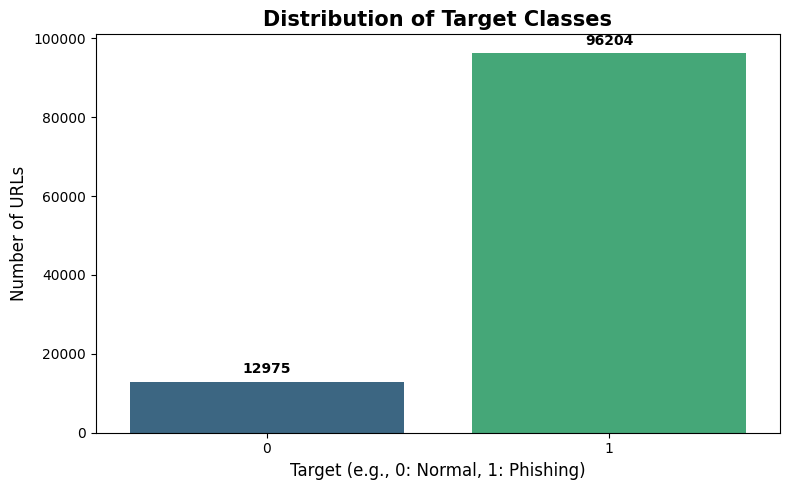

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Target 的數量與比例 ---
target_counts = df_final['target'].value_counts()
target_percentages = df_final['target'].value_counts(normalize=True) * 100

print("=== 📊 Target 數量分布 ===")
print(target_counts)
print("\n=== 📈 Target 比例分布 (%) ===")
print(target_percentages.round(2))

# --- 柱狀圖 ---
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_final, x='target', palette='viridis')

plt.title('Distribution of Target Classes', fontsize=15, fontweight='bold')
plt.xlabel('Target (e.g., 0: Normal, 1: Phishing)', fontsize=12)
plt.ylabel('Number of URLs', fontsize=12)

# 在柱子上加上具體的數字標籤
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
df_final.to_csv("phishing_dataset_COMPLETE.csv", index=False)
print("🎉 最終整合資料集已儲存為 phishing_dataset_COMPLETE.csv")

🎉 最終整合資料集已儲存為 phishing_dataset_COMPLETE.csv


In [9]:
# 替換成報錯的那個檔案路徑 (例如你的 html_name 或 ai_name)
file_path = "/content/drive/MyDrive/畢業專題資料集/phishing_dataset_HTML.csv"

last_good_line = ""

print(f"🕵️ 開始逐行掃描檔案：{file_path}")

# 以二進位 ('rb') 模式讀取，這樣 Python 就不會在讀檔的瞬間當機
with open(file_path, 'rb') as f:
    for i, line_bytes in enumerate(f):
        try:
            # 嘗試把這一行的二進位資料解碼成 utf-8
            line_str = line_bytes.decode('utf-8')
            last_good_line = line_str # 如果成功，就記住這行正常的資料

        except UnicodeDecodeError as e:
            print("\n🚨 抓到元兇了！")
            print(f"❌ 錯誤發生在 CSV 的第 {i + 1} 行 (包含第一行的標題列)")

            # 印出上一行正常的資料，幫助你定位這是哪個 URL
            print("\n✅ 錯誤前一行的正常資料是:")
            print(last_good_line.strip())

            # 印出導致當機的亂碼長什麼樣子
            print("\n👽 導致當機的原始位元組 (亂碼):")
            print(line_bytes)
            break

print("掃描結束。")

🕵️ 開始逐行掃描檔案：/content/drive/MyDrive/畢業專題資料集/phishing_dataset_HTML.csv
掃描結束。
